In [150]:
import numpyro
numpyro.set_host_device_count(4)

import numpy as np
import matplotlib.pyplot as plt


from candel.inference import run_MWCepheids_inference
from candel.model import MWCepheidModel
from candel.mock.ppc_mwcepheids import generate_ppc
from candel import load_config
from candel.pvdata import CepheidData, to_mwcepheids_config
from mwcepheids_plotting import plot_corner, plot_ppc, plot_trace

%matplotlib inline

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [151]:
config = to_mwcepheids_config(load_config("../scripts/config.toml", replace_los_prior=False))
data = CepheidData(config)

2026-02-23 11:46:11 ============================================================
2026-02-23 11:46:11 Model Configuration
2026-02-23 11:46:11 ============================================================
2026-02-23 11:46:11   Model type      : forward
2026-02-23 11:46:11   Distance prior  : disk
2026-02-23 11:46:11   Scatter         : per-campaign
2026-02-23 11:46:11   Q index         : disabled
2026-02-23 11:46:11   Spiral arms     : disabled
2026-02-23 11:46:11 ------------------------------------------------------------
2026-02-23 11:46:11 C22 Selection
2026-02-23 11:46:11 ------------------------------------------------------------
2026-02-23 11:46:11   mW selection    : ENABLED
2026-02-23 11:46:11   mW_max          : infer
2026-02-23 11:46:11   mW_width        : 0.500
2026-02-23 11:46:11   AH selection    : disabled
2026-02-23 11:46:11   pi selection    : ENABLED
2026-02-23 11:46:11   pi_min          : infer
2026-02-23 11:46:11   pi_smooth       : True
2026-02-23 11:46:11   pi_width

In [152]:
model = MWCepheidModel(config, data)
mcmc, samples = run_MWCepheids_inference(
    model, save_samples=False, return_mcmc=True)

2026-02-23 11:46:12 Running inference on devices: cpu(cpu), cpu(cpu), cpu(cpu), cpu(cpu)


2026-02-23 11:46:12 Using NumPyro platform: CPU
2026-02-23 11:46:12 Loaded C22 MC sightlines from spiral cache (1000)
2026-02-23 11:46:12 Dense mass blocks: [('M_H_1', 'b_W', 'Z_W', 'delta_pi'), ('mu_logP_C22', 'sigma_logP_C22')]


sample: 100%|██████████| 2000/2000 [00:19<00:00, 104.40it/s, 31 steps of size 1.50e-01. acc. prob=0.91]


                      mean        std     median       5.0%      95.0%      n_eff      r_hat
-----------------------------------------------------------------------------------------------
          M_H_1     -5.750      0.050     -5.752     -5.829     -5.668      149.2      1.002
            Z_W     -0.310      0.194     -0.302     -0.621      0.007      383.0      0.999
            b_W     -3.505      0.111     -3.508     -3.681     -3.323      449.9      0.999
       delta_pi      0.002      0.007      0.002     -0.009      0.012      139.3      1.006
     mW_max_C22      7.363      0.452      7.321      6.685      7.913      507.3      1.000
      mu_OH_C22      0.152      0.022      0.152      0.118      0.191      678.3      0.999
    mu_logP_C22      0.567      0.424      0.663     -0.041      1.140      286.4      1.004
     pi_min_C22      0.336      0.031      0.339      0.288      0.387      782.3      0.999
   sigma_OH_C22      0.127      0.017      0.126      0.099      0

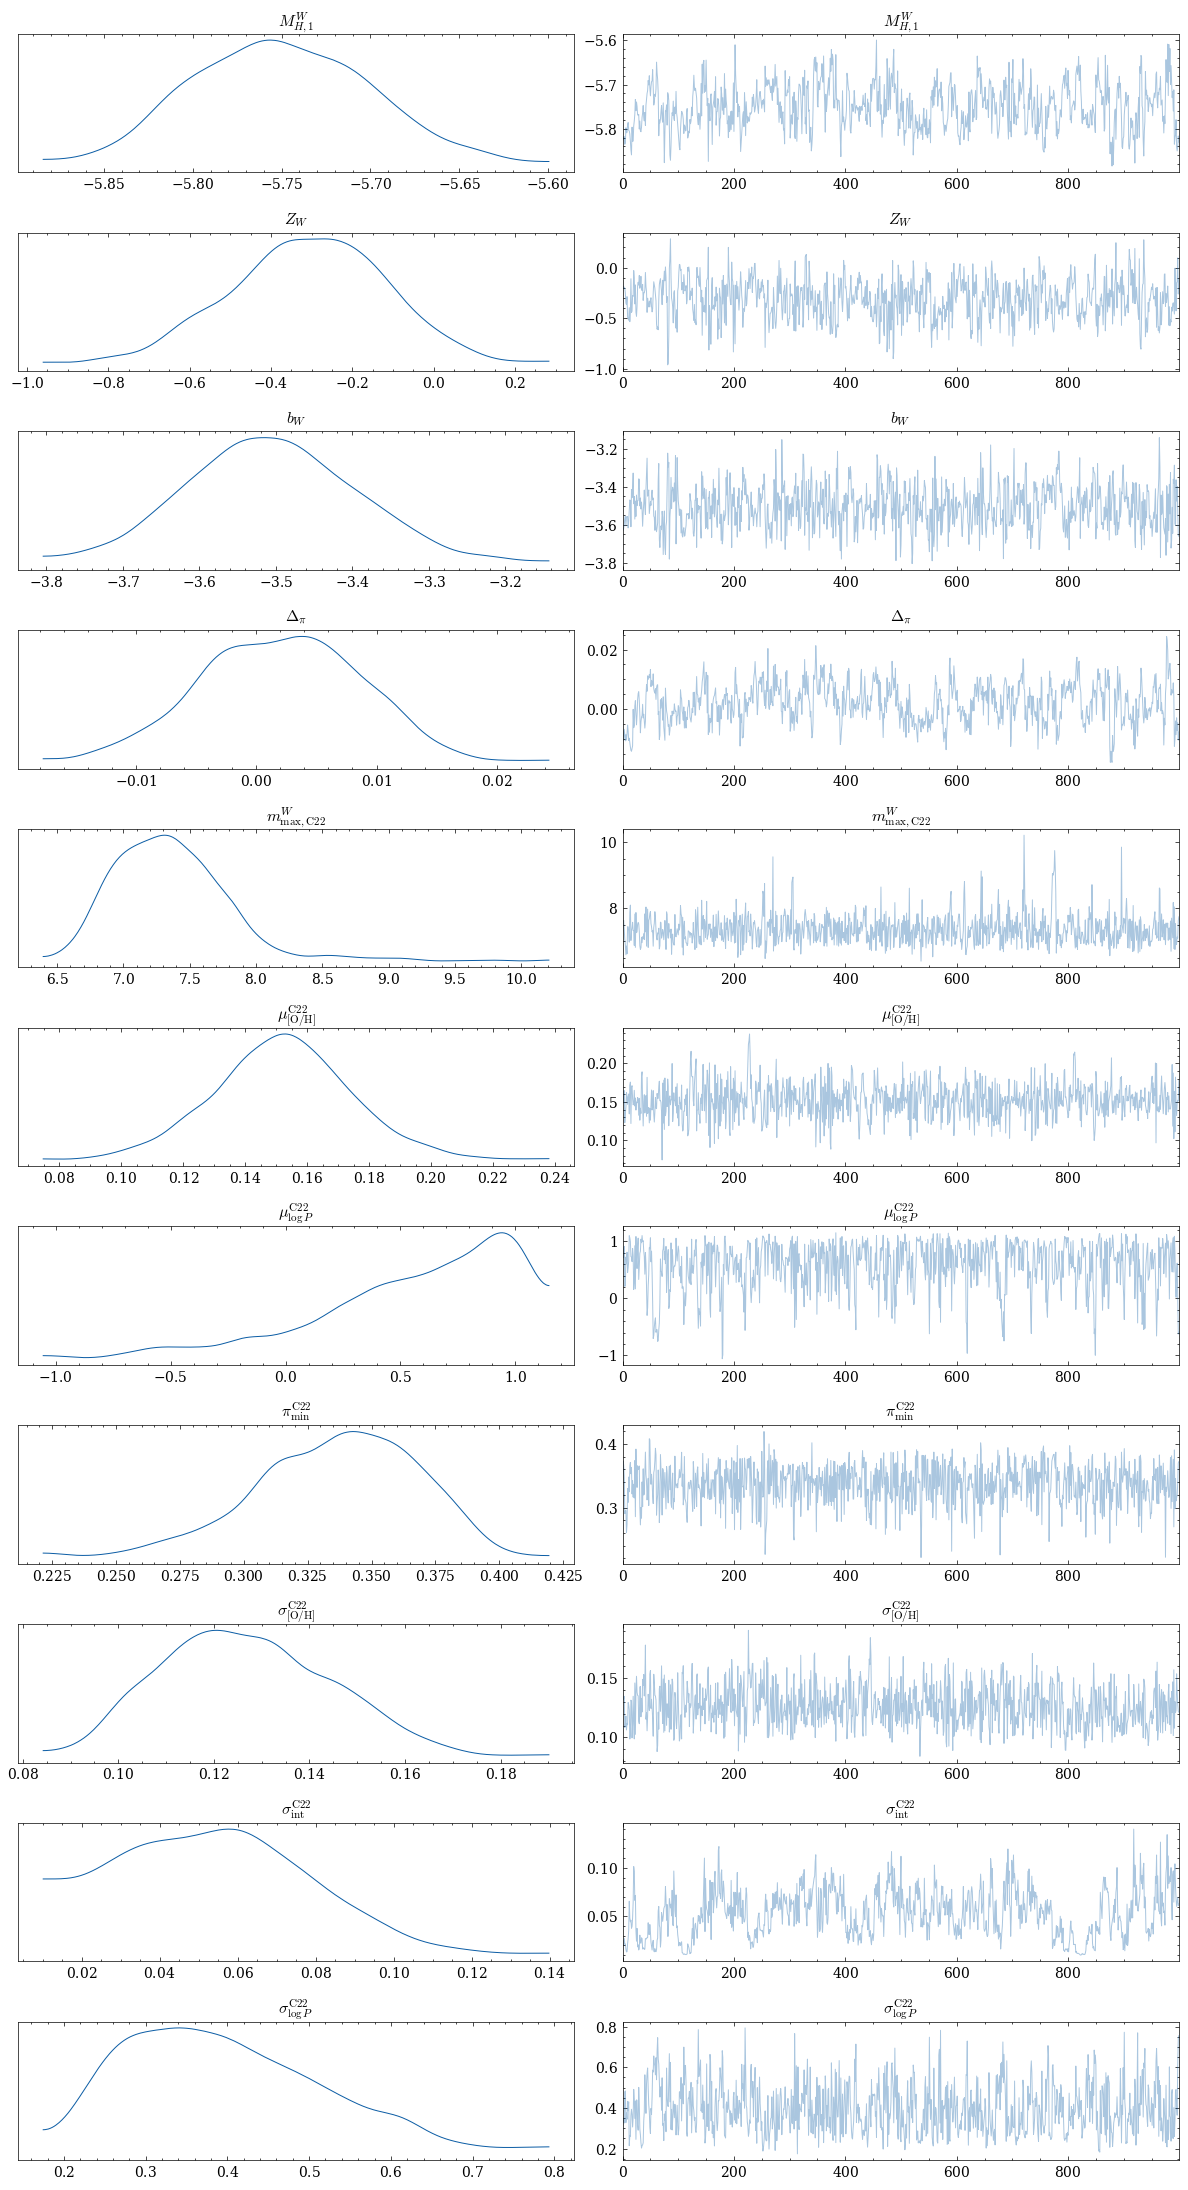

In [153]:
display(plot_trace(mcmc, exclude=["d_C22", "d_C27"]))

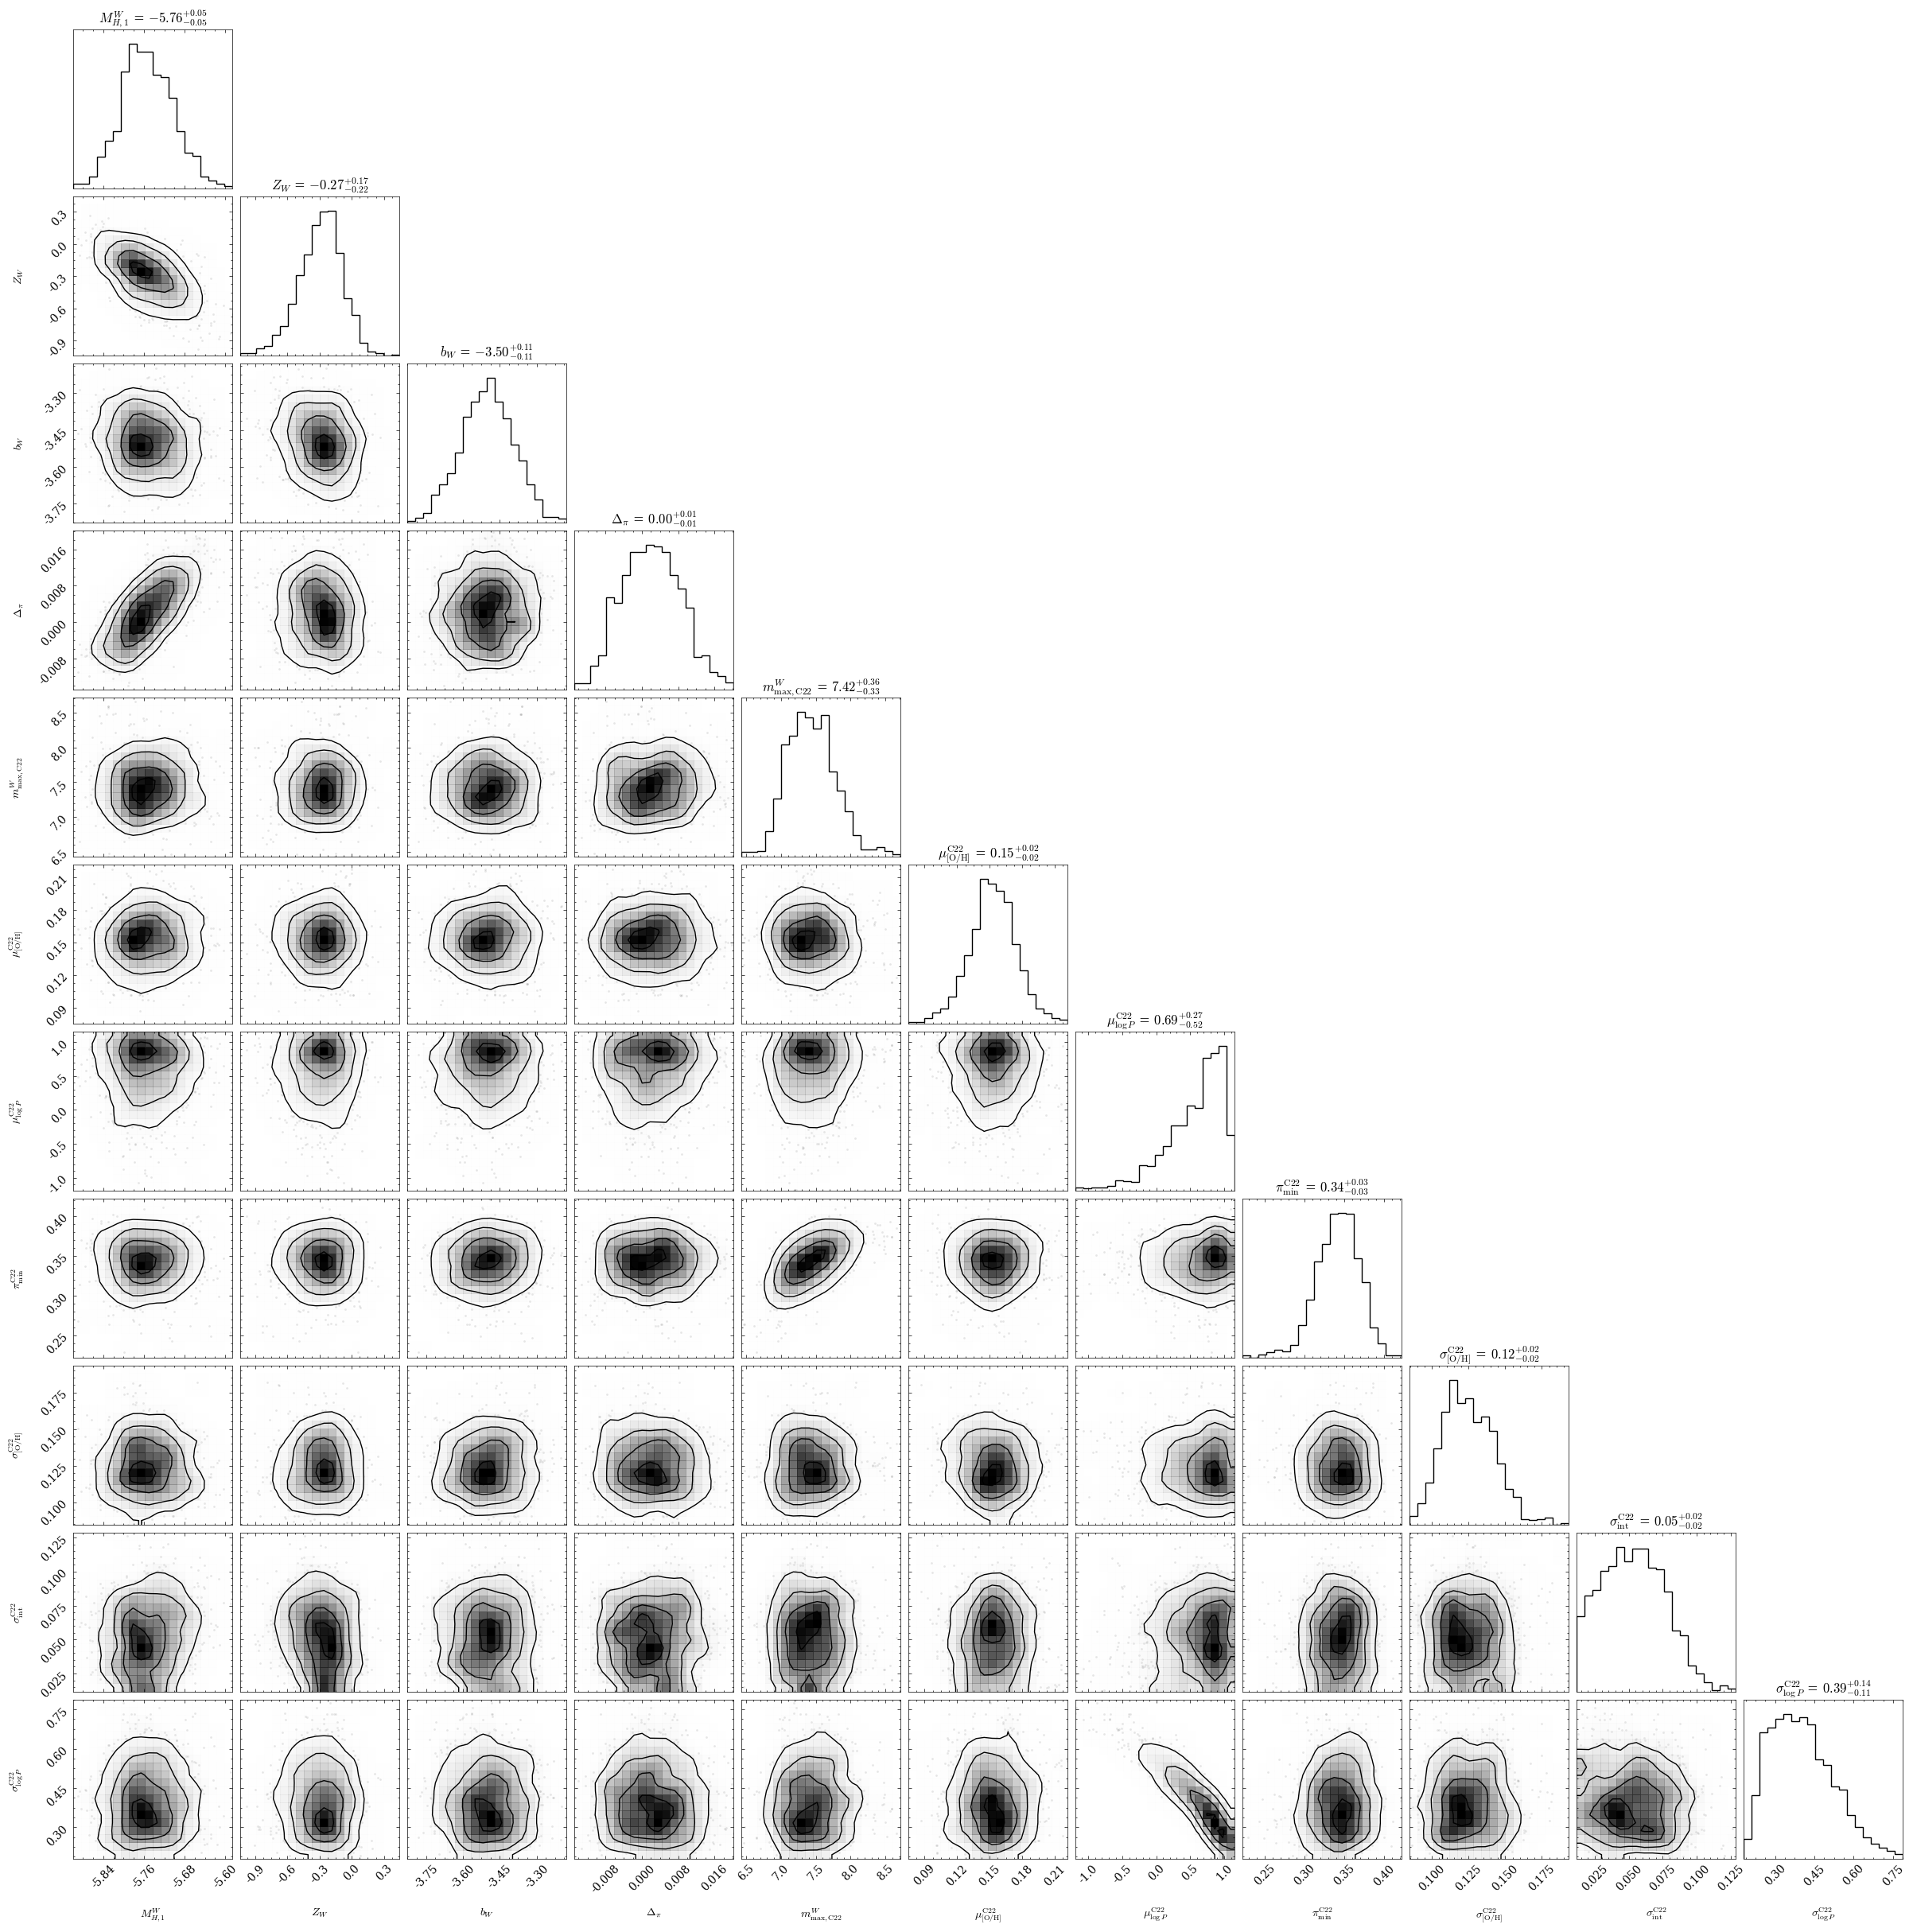

In [147]:
fig = plot_corner(mcmc, exclude=["d_C22", "d_C27"])

fig.savefig("/Users/rstiskalek/Downloads/corner.png", dpi=300, bbox_inches="tight")
display(fig)

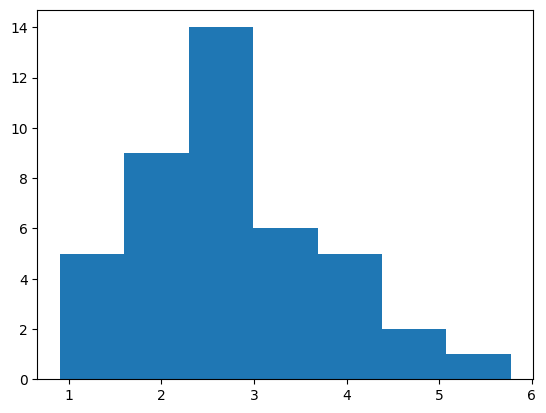

In [148]:
plt.figure()
if "d_C22" in samples:
    key = "d_C22"
elif "d_C27" in samples:
    key = "d_C27"
else:
    raise ValueError("No d_C22 or d_C27 in samples")
plt.hist(np.mean(samples[key], axis=0), bins="auto")

plt.show()

2026-02-23 11:45:15 PPC (C22): d = [0.45, 8.50] kpc, prior = disk
2026-02-23 11:45:15   C22 mW upper selection (mW_max = infer)
2026-02-23 11:45:15   C22 pi selection (pi_min = infer, smooth = True)
2026-02-23 11:45:15   C22 logP selection (logP_min = 0.903)
2026-02-23 11:45:15   Loaded 5000 MC sightlines from spiral cache


PPC (C22):   0%|          | 0/42000 [00:00<?, ?samples/s]

2026-02-23 11:45:24   PPC acceptance: 60261/2690857 (2.2%), batches=2
2026-02-23 11:45:24   PPC 0: KS(mW) p=0.2513, KS(pi) p=0.2168, KS(logP) p=0.9929


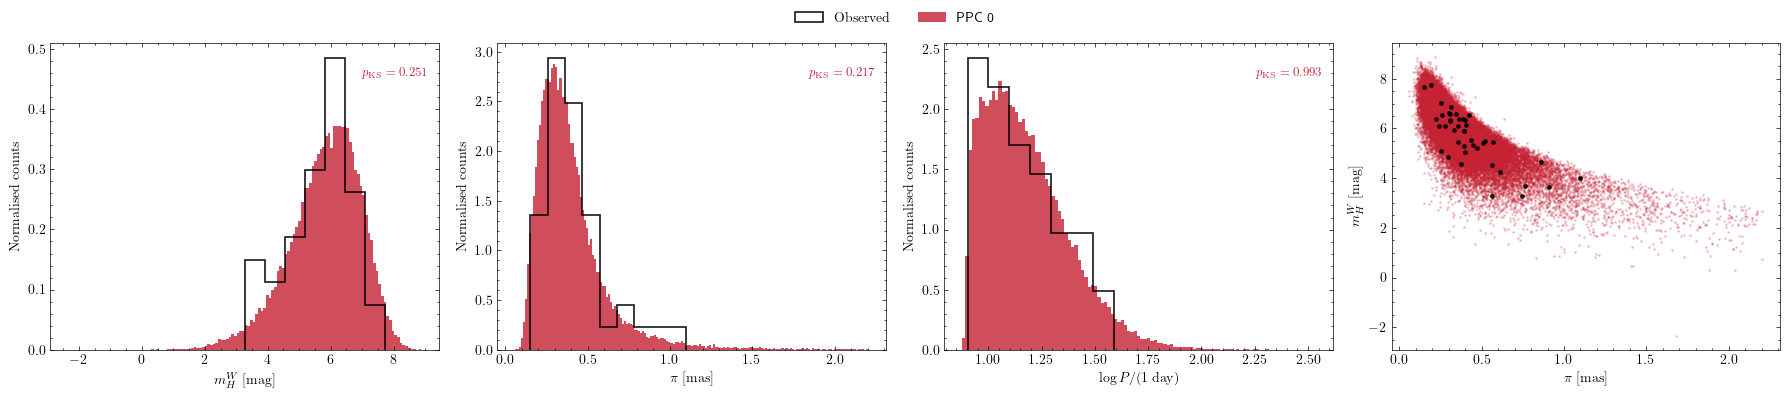

In [149]:
# Posterior predictive check
ppc_results = generate_ppc(samples, data, config)
fig = plot_ppc(ppc_results)

fig.savefig("/Users/rstiskalek/Downloads/PPC.png", dpi=450, bbox_inches="tight")

display(fig)